# Bessel Functions: A Brief Overview

Antonio C. S. Lima

EE457 Transmissão de Energia Elétrica

Março 2026



Bessel functions arise as solutions to **Bessel's differential equation**:

$$x^2 \frac{d^2 y}{dx^2} + x \frac{dy}{dx} + \left(x^2 - \nu^2\right) y = 0$$

where $\nu$ is the **order** (real or complex). They appear ubiquitously in problems with cylindrical or spherical symmetry — electromagnetic wave propagation, heat conduction, vibration of membranes, and ground-return impedance in transmission lines.

There are four canonical Bessel functions:

| Function | Symbol | Type | Domain |
|---|---|---|---|
| Bessel of the 1st kind | $J_\nu(x)$ | Oscillatory | $x \in \mathbb{R}$ |
| Bessel of the 2nd kind | $Y_\nu(x)$ | Oscillatory + singular at 0 | $x > 0$ |
| Modified Bessel 1st kind | $I_\nu(x)$ | Monotone (exponential growth) | $x \in \mathbb{R}$ |
| Modified Bessel 2nd kind | $K_\nu(x)$ | Monotone (exponential decay) | $x > 0$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import jv, yv, iv, kv

# Plot style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'lines.linewidth': 2.0,
    'figure.dpi': 120,
})

# Okabe-Ito colorblind-safe palette
COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

print("Libraries loaded. SciPy version:", __import__('scipy').__version__)

Libraries loaded. SciPy version: 1.17.0


---
## 1. Bessel Functions of the First Kind — $J_\nu(x)$

**Definition (series):**
$$J_\nu(x) = \sum_{m=0}^{\infty} \frac{(-1)^m}{m!\,\Gamma(m+\nu+1)} \left(\frac{x}{2}\right)^{2m+\nu}$$

**Key properties:**
- Oscillatory and bounded for all real $x$
- $J_\nu(0) = 1$ if $\nu=0$, and $J_\nu(0) = 0$ if $\nu > 0$
- Infinitely many positive zeros; zeros of $J_0, J_1, \ldots$ interleave
- Large-argument asymptotic: $J_\nu(x) \approx \sqrt{\dfrac{2}{\pi x}}\cos\!\left(x - \dfrac{\nu\pi}{2} - \dfrac{\pi}{4}\right)$ as $x\to\infty$
- Recurrence: $J_{\nu-1}(x) + J_{\nu+1}(x) = \dfrac{2\nu}{x}J_\nu(x)$

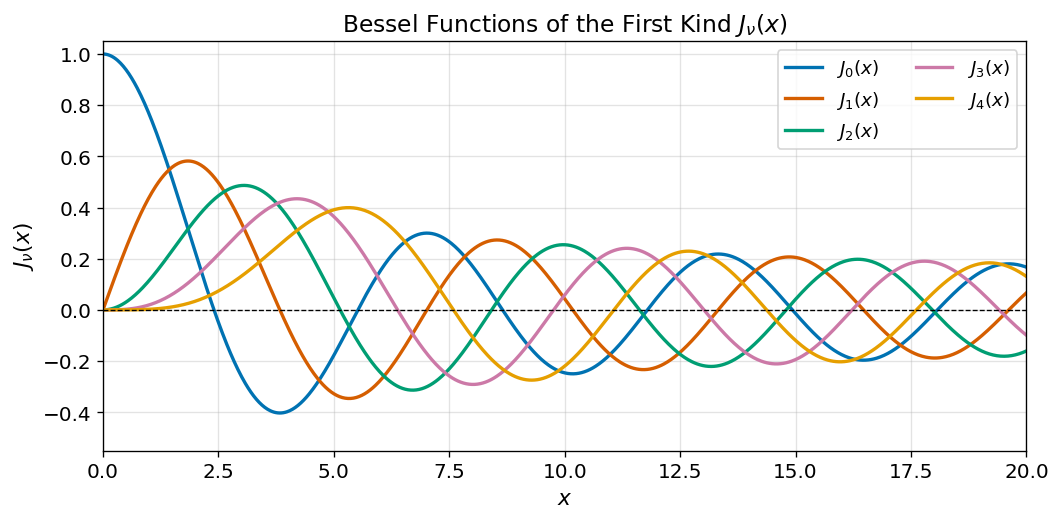

In [2]:
x = np.linspace(0, 20, 1000)
orders = [0, 1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(9, 4.5))
for nu, c in zip(orders, COLORS):
    ax.plot(x, jv(nu, x), color=c, label=rf'$J_{{{nu}}}(x)$')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlim(0, 20)
ax.set_ylim(-0.55, 1.05)
ax.set_xlabel('$x$')
ax.set_ylabel('$J_\\nu(x)$')
ax.set_title('Bessel Functions of the First Kind $J_\\nu(x)$')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 2. Bessel Functions of the Second Kind — $Y_\nu(x)$

Also called **Neumann functions** ($N_\nu$), $Y_\nu$ is the second linearly independent solution of Bessel's equation.

**Definition (integer order $n$):**
$$Y_n(x) = \frac{2}{\pi}\left[\ln\frac{x}{2} + \gamma_E\right]J_n(x) - \frac{1}{\pi}\sum_{k=0}^{n-1}\frac{(n-k-1)!}{k!}\left(\frac{x}{2}\right)^{2k-n} - \frac{1}{\pi}\sum_{k=0}^{\infty}\frac{(-1)^k}{k!(n+k)!}\left(\frac{x}{2}\right)^{2k+n}[\psi(k+1)+\psi(n+k+1)]$$

where $\gamma_E \approx 0.5772$ is the Euler–Mascheroni constant and $\psi$ is the digamma function.

**Key properties:**
- **Singular at $x = 0$**: $Y_\nu(x) \to -\infty$ as $x \to 0^+$ — excluded in problems with $r=0$
- Oscillatory for large $x$, with same asymptotic amplitude as $J_\nu$
- Large-argument: $Y_\nu(x) \approx \sqrt{\dfrac{2}{\pi x}}\sin\!\left(x - \dfrac{\nu\pi}{2} - \dfrac{\pi}{4}\right)$ as $x\to\infty$
- $J_\nu$ and $Y_\nu$ form a fundamental pair: their Wronskian is $W\{J_\nu, Y_\nu\} = \dfrac{2}{\pi x}$

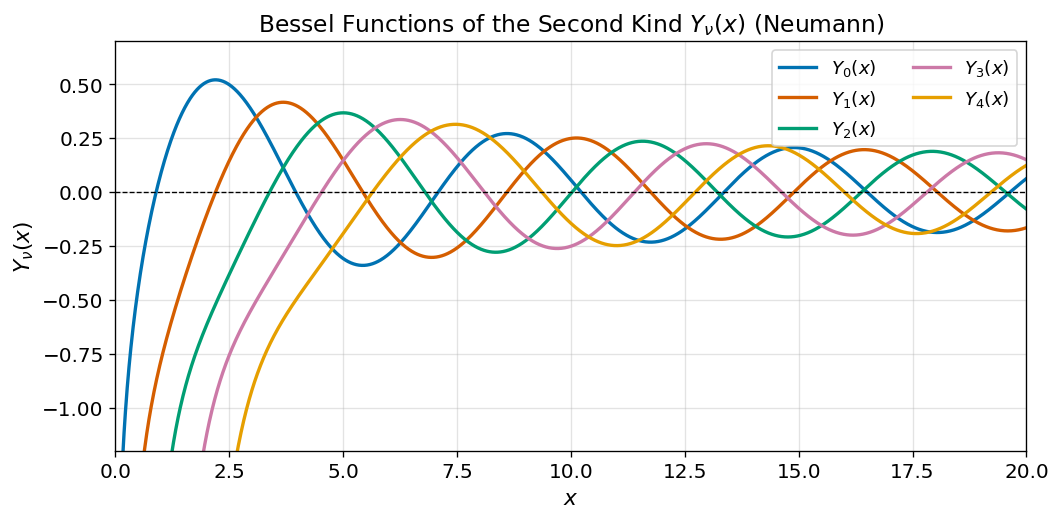

In [3]:
x = np.linspace(0.1, 20, 2000)  # start away from 0 (singularity)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nu, c in zip(orders, COLORS):
    y_vals = yv(nu, x)
    ax.plot(x, np.clip(y_vals, -2.5, 2.5), color=c, label=rf'$Y_{{{nu}}}(x)$')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlim(0, 20)
ax.set_ylim(-1.2, 0.7)
ax.set_xlabel('$x$')
ax.set_ylabel('$Y_\\nu(x)$')
ax.set_title('Bessel Functions of the Second Kind $Y_\\nu(x)$ (Neumann)')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 3. Modified Bessel Functions of the First Kind — $I_\nu(x)$

$I_\nu$ solves the **modified Bessel equation** (argument replaced by $ix$):

$$x^2 y'' + x y' - (x^2 + \nu^2)y = 0$$

**Definition:**
$$I_\nu(x) = i^{-\nu} J_\nu(ix) = \sum_{m=0}^{\infty} \frac{1}{m!\,\Gamma(m+\nu+1)} \left(\frac{x}{2}\right)^{2m+\nu}$$

**Key properties:**
- **Monotonically increasing**, no oscillations
- $I_0(0) = 1$; $I_\nu(0) = 0$ for $\nu > 0$
- Grows **exponentially**: $I_\nu(x) \approx \dfrac{e^x}{\sqrt{2\pi x}}$ as $x \to \infty$
- Appears in problems with pure imaginary argument (e.g., skin effect, diffusion)
- Recurrence: $I_{\nu-1}(x) - I_{\nu+1}(x) = \dfrac{2\nu}{x}I_\nu(x)$

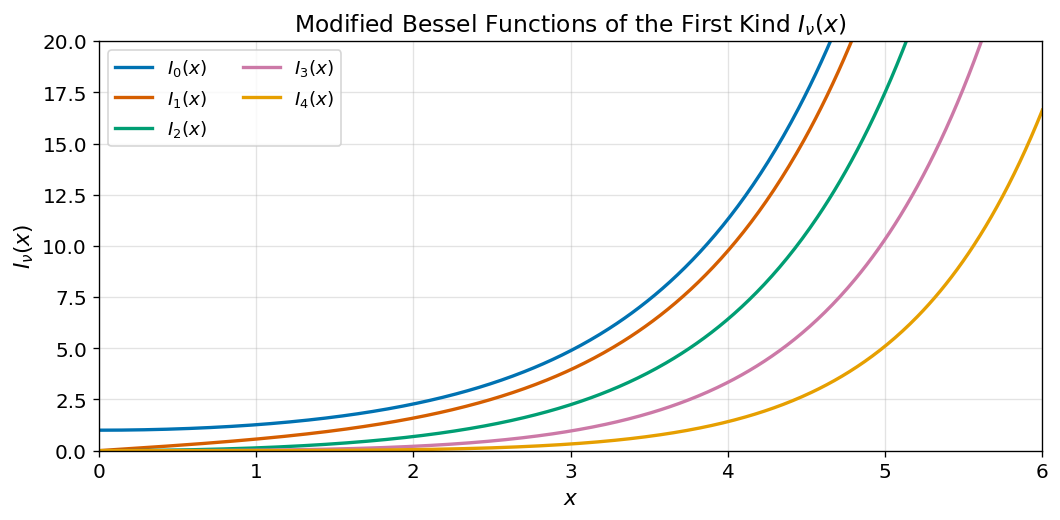

In [4]:
x = np.linspace(0, 6, 500)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nu, c in zip(orders, COLORS):
    ax.plot(x, iv(nu, x), color=c, label=rf'$I_{{{nu}}}(x)$')

ax.set_xlim(0, 6)
ax.set_ylim(0, 20)
ax.set_xlabel('$x$')
ax.set_ylabel('$I_\\nu(x)$')
ax.set_title('Modified Bessel Functions of the First Kind $I_\\nu(x)$')
ax.legend(loc='upper left', ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 4. Modified Bessel Functions of the Second Kind — $K_\nu(x)$

$K_\nu$ is the second independent solution of the modified Bessel equation, defined to decay at infinity.

**Definition:**
$$K_\nu(x) = \frac{\pi}{2} \frac{I_{-\nu}(x) - I_{\nu}(x)}{\sin(\nu\pi)}$$

**Key properties:**
- **Singular at $x = 0$** and decays **exponentially** for large $x$
- $K_\nu(x) \approx \sqrt{\dfrac{\pi}{2x}} e^{-x}$ as $x \to \infty$ (universal for all $\nu$)
- The pair $(I_\nu, K_\nu)$ is to the modified equation what $(J_\nu, Y_\nu)$ is to the original
- Wronskian: $W\{I_\nu, K_\nu\} = -\dfrac{1}{x}$
- Crucial in ground-return impedance and skin-effect formulas (Schelkunoff, Carson, Ametani)

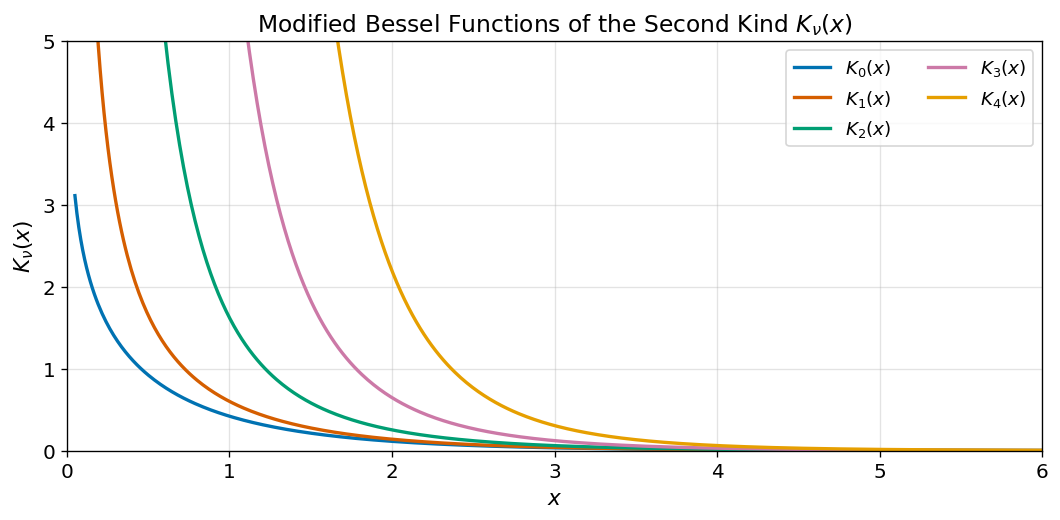

In [5]:
x = np.linspace(0.05, 6, 500)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nu, c in zip(orders, COLORS):
    ax.plot(x, kv(nu, x), color=c, label=rf'$K_{{{nu}}}(x)$')

ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.set_xlabel('$x$')
ax.set_ylabel('$K_\\nu(x)$')
ax.set_title('Modified Bessel Functions of the Second Kind $K_\\nu(x)$')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 5. Summary Panel — All Four Functions (Order $\nu = 0$)

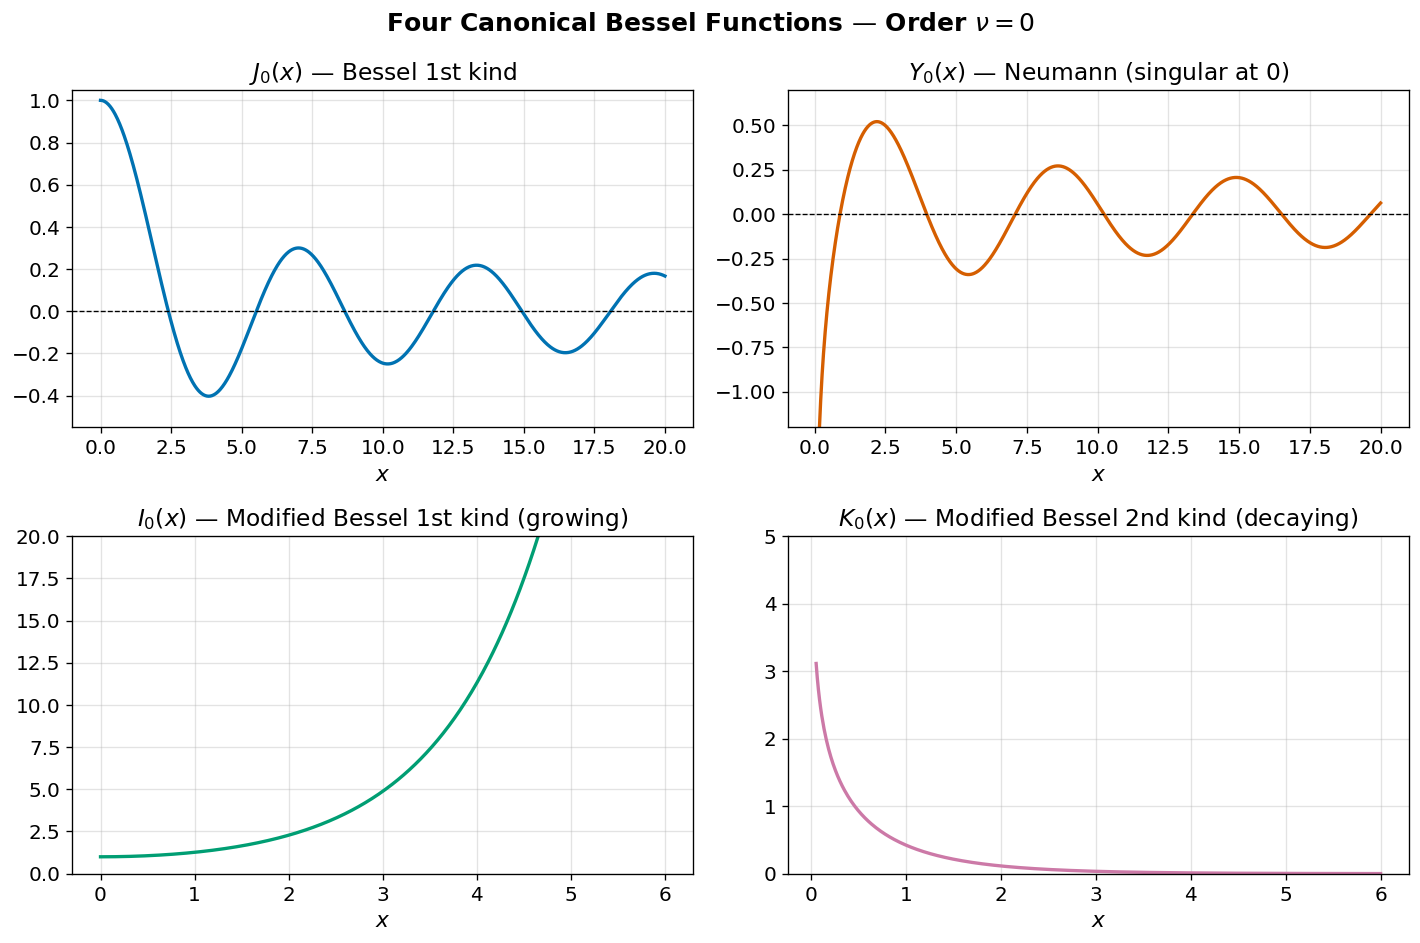

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
nu = 0
panel_color = COLORS[0]

# --- J0 ---
x = np.linspace(0, 20, 1000)
axes[0, 0].plot(x, jv(nu, x), color=COLORS[0])
axes[0, 0].axhline(0, color='k', lw=0.8, ls='--')
axes[0, 0].set_title(r'$J_0(x)$ — Bessel 1st kind')
axes[0, 0].set_ylim(-0.55, 1.05)
axes[0, 0].grid(True, alpha=0.35)

# --- Y0 ---
x = np.linspace(0.05, 20, 2000)
axes[0, 1].plot(x, np.clip(yv(nu, x), -2, 2), color=COLORS[1])
axes[0, 1].axhline(0, color='k', lw=0.8, ls='--')
axes[0, 1].set_title(r'$Y_0(x)$ — Neumann (singular at 0)')
axes[0, 1].set_ylim(-1.2, 0.7)
axes[0, 1].grid(True, alpha=0.35)

# --- I0 ---
x = np.linspace(0, 6, 500)
axes[1, 0].plot(x, iv(nu, x), color=COLORS[2])
axes[1, 0].set_title(r'$I_0(x)$ — Modified Bessel 1st kind (growing)')
axes[1, 0].set_ylim(0, 20)
axes[1, 0].grid(True, alpha=0.35)

# --- K0 ---
x = np.linspace(0.05, 6, 500)
axes[1, 1].plot(x, kv(nu, x), color=COLORS[3])
axes[1, 1].set_title(r'$K_0(x)$ — Modified Bessel 2nd kind (decaying)')
axes[1, 1].set_ylim(0, 5)
axes[1, 1].grid(True, alpha=0.35)

for ax in axes.flat:
    ax.set_xlabel('$x$')

fig.suptitle('Four Canonical Bessel Functions — Order $\\nu = 0$', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Asymptotic Behavior Verification

For large $x$, the oscillatory pair behaves as:

$$J_\nu(x) \sim \sqrt{\frac{2}{\pi x}}\cos\!\left(x - \frac{\nu\pi}{2} - \frac{\pi}{4}\right), \qquad Y_\nu(x) \sim \sqrt{\frac{2}{\pi x}}\sin\!\left(x - \frac{\nu\pi}{2} - \frac{\pi}{4}\right)$$

The exponential pair obeys:

$$I_\nu(x) \sim \frac{e^x}{\sqrt{2\pi x}}, \qquad K_\nu(x) \sim \sqrt{\frac{\pi}{2x}}\,e^{-x}$$

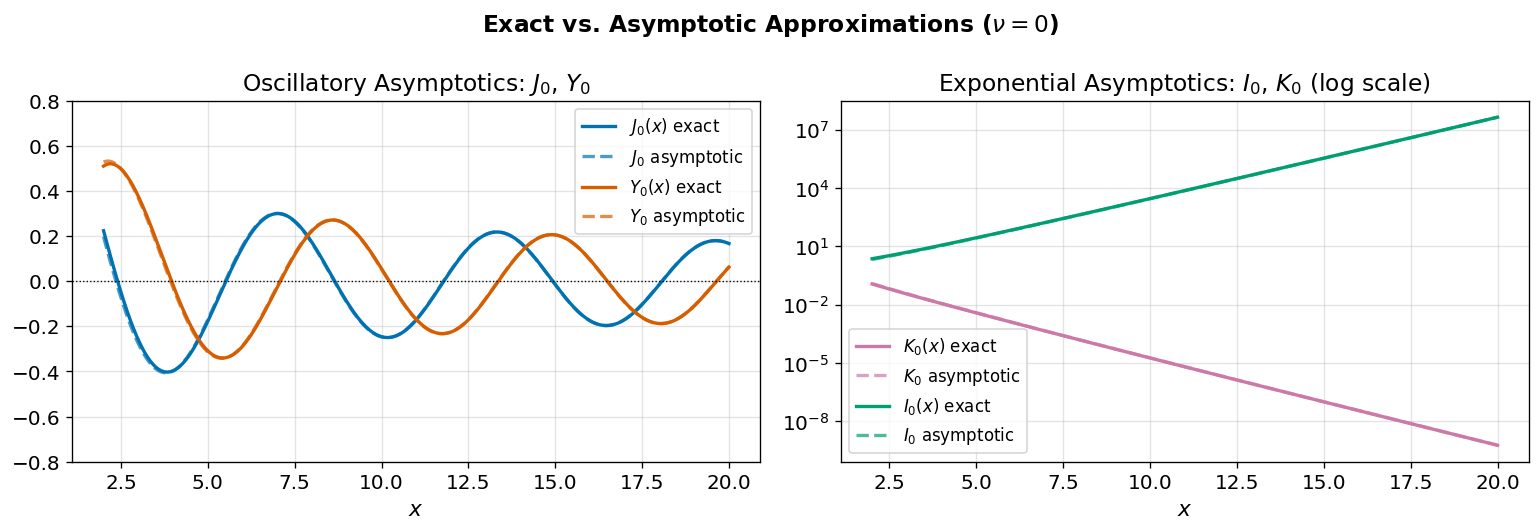

In [7]:
x = np.linspace(2, 20, 1000)
nu = 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- J0 and Y0 vs asymptotic ---
J0_asym = np.sqrt(2 / (np.pi * x)) * np.cos(x - np.pi/4)
Y0_asym = np.sqrt(2 / (np.pi * x)) * np.sin(x - np.pi/4)

axes[0].plot(x, jv(0, x), color=COLORS[0], label=r'$J_0(x)$ exact')
axes[0].plot(x, J0_asym, color=COLORS[0], ls='--', alpha=0.7, label=r'$J_0$ asymptotic')
axes[0].plot(x, yv(0, x), color=COLORS[1], label=r'$Y_0(x)$ exact')
axes[0].plot(x, Y0_asym, color=COLORS[1], ls='--', alpha=0.7, label=r'$Y_0$ asymptotic')
axes[0].axhline(0, color='k', lw=0.8, ls=':')
axes[0].set_ylim(-0.8, 0.8)
axes[0].set_title(r'Oscillatory Asymptotics: $J_0$, $Y_0$')
axes[0].set_xlabel('$x$')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.35)

# --- K0 vs asymptotic (log scale) ---
K0_asym = np.sqrt(np.pi / (2 * x)) * np.exp(-x)
I0_asym = np.exp(x) / np.sqrt(2 * np.pi * x)

axes[1].semilogy(x, kv(0, x), color=COLORS[3], label=r'$K_0(x)$ exact')
axes[1].semilogy(x, K0_asym, color=COLORS[3], ls='--', alpha=0.7, label=r'$K_0$ asymptotic')
axes[1].semilogy(x, iv(0, x), color=COLORS[2], label=r'$I_0(x)$ exact')
axes[1].semilogy(x, I0_asym, color=COLORS[2], ls='--', alpha=0.7, label=r'$I_0$ asymptotic')
axes[1].set_title(r'Exponential Asymptotics: $I_0$, $K_0$ (log scale)')
axes[1].set_xlabel('$x$')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.35, which='both')

fig.suptitle('Exact vs. Asymptotic Approximations ($\\nu = 0$)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Zeros of $J_\nu(x)$

The zeros of $J_\nu$ are the eigenvalues in many boundary-value problems (e.g., waveguide modes, vibrating circular membranes). SciPy provides them via `jn_zeros`.

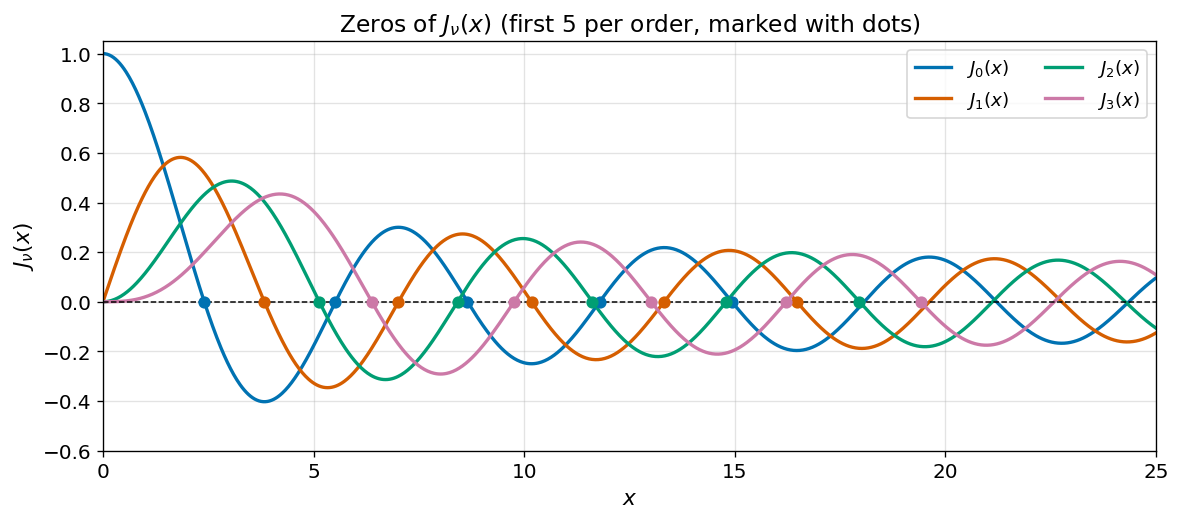

First 5 zeros of J_0: [ 2.40483  5.52008  8.65373 11.79153 14.93092]
First 5 zeros of J_1: [ 3.83171  7.01559 10.17347 13.32369 16.47063]


In [8]:
from scipy.special import jn_zeros

x = np.linspace(0, 25, 1000)

fig, ax = plt.subplots(figsize=(10, 4.5))
for nu, c in zip([0, 1, 2, 3], COLORS):
    ax.plot(x, jv(nu, x), color=c, label=rf'$J_{{{nu}}}(x)$')
    zeros = jn_zeros(nu, 5)
    ax.scatter(zeros, np.zeros_like(zeros), color=c, zorder=5, s=40)

ax.axhline(0, color='k', lw=0.9, ls='--')
ax.set_xlim(0, 25)
ax.set_ylim(-0.6, 1.05)
ax.set_xlabel('$x$')
ax.set_ylabel('$J_\\nu(x)$')
ax.set_title('Zeros of $J_\\nu(x)$ (first 5 per order, marked with dots)')
ax.legend(ncol=2)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print("First 5 zeros of J_0:", np.round(jn_zeros(0, 5), 5))
print("First 5 zeros of J_1:", np.round(jn_zeros(1, 5), 5))

---
## 8. Hankel Functions (Complex combinations)

The **Hankel functions** (Bessel functions of the 3rd kind) are complex linear combinations of $J_\nu$ and $Y_\nu$:

$$H_\nu^{(1)}(x) = J_\nu(x) + i\,Y_\nu(x), \qquad H_\nu^{(2)}(x) = J_\nu(x) - i\,Y_\nu(x)$$

These represent **outgoing** and **incoming** cylindrical waves respectively, analogous to $e^{\pm ikx}$ in Cartesian coordinates. Their large-argument behavior:

$$H_\nu^{(1)}(x) \sim \sqrt{\frac{2}{\pi x}}\,e^{i(x - \nu\pi/2 - \pi/4)}, \quad H_\nu^{(2)}(x) \sim \sqrt{\frac{2}{\pi x}}\,e^{-i(x - \nu\pi/2 - \pi/4)}$$

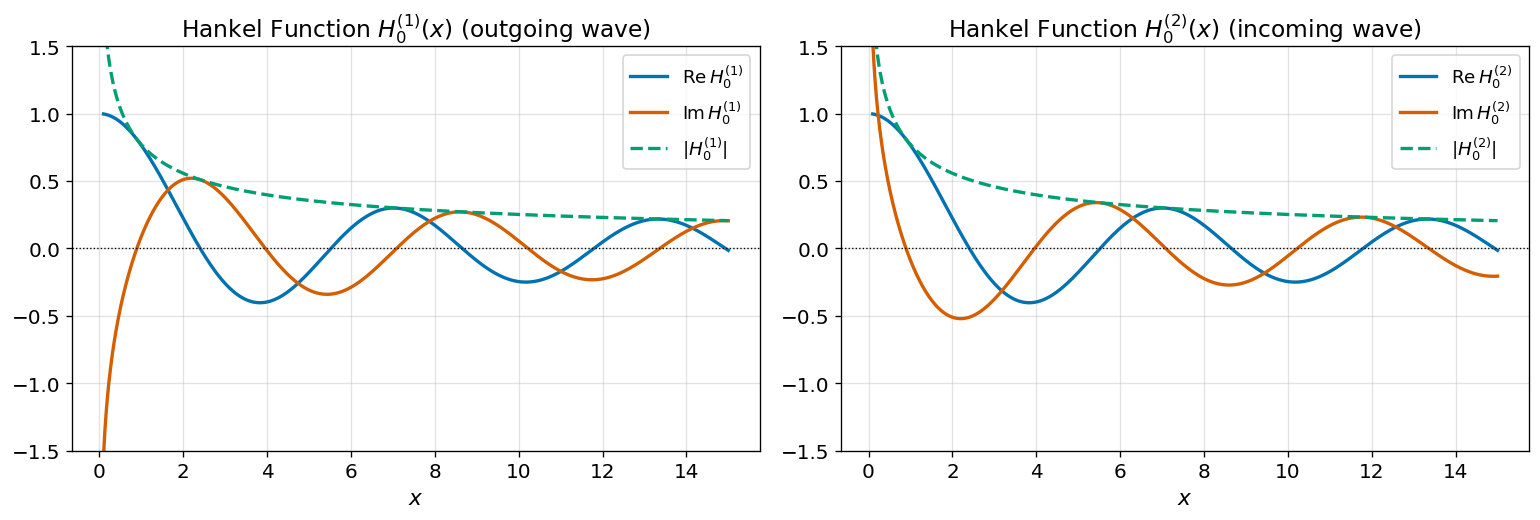

In [9]:
from scipy.special import hankel1, hankel2

x = np.linspace(0.1, 15, 1000)
nu = 0

H1 = hankel1(nu, x)
H2 = hankel2(nu, x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(x, H1.real, color=COLORS[0], label=r'$\mathrm{Re}\,H_0^{(1)}$')
axes[0].plot(x, H1.imag, color=COLORS[1], label=r'$\mathrm{Im}\,H_0^{(1)}$')
axes[0].plot(x, np.abs(H1), color=COLORS[2], ls='--', label=r'$|H_0^{(1)}|$')
axes[0].axhline(0, color='k', lw=0.8, ls=':')
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title(r'Hankel Function $H_0^{(1)}(x)$ (outgoing wave)')
axes[0].set_xlabel('$x$')
axes[0].legend()
axes[0].grid(True, alpha=0.35)

axes[1].plot(x, H2.real, color=COLORS[0], label=r'$\mathrm{Re}\,H_0^{(2)}$')
axes[1].plot(x, H2.imag, color=COLORS[1], label=r'$\mathrm{Im}\,H_0^{(2)}$')
axes[1].plot(x, np.abs(H2), color=COLORS[2], ls='--', label=r'$|H_0^{(2)}|$')
axes[1].axhline(0, color='k', lw=0.8, ls=':')
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_title(r'Hankel Function $H_0^{(2)}(x)$ (incoming wave)')
axes[1].set_xlabel('$x$')
axes[1].legend()
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

---
## 9. Quick Reference

| | $J_\nu(x)$ | $Y_\nu(x)$ | $I_\nu(x)$ | $K_\nu(x)$ |
|---|---|---|---|---|
| **ODE** | Bessel | Bessel | Modified Bessel | Modified Bessel |
| **At $x=0$** | Finite | $-\infty$ | Finite | $+\infty$ |
| **At $x\to\infty$** | Oscillatory $\sim x^{-1/2}$ | Oscillatory $\sim x^{-1/2}$ | Grows $\sim e^x/\sqrt{x}$ | Decays $\sim e^{-x}/\sqrt{x}$ |
| **Zeros** | Infinitely many | Infinitely many | None (for real $x>0$) | None |
| **SciPy** | `jv(nu, x)` | `yv(nu, x)` | `iv(nu, x)` | `kv(nu, x)` |
| **Mathematica** | `BesselJ[nu,x]` | `BesselY[nu,x]` | `BesselI[nu,x]` | `BesselK[nu,x]` |

### Connection formulas
$$I_\nu(x) = i^{-\nu} J_\nu(ix), \qquad K_\nu(x) = \frac{\pi}{2} i^{\nu+1} H_\nu^{(1)}(ix)$$
$$H_\nu^{(1)} = J_\nu + iY_\nu, \qquad H_\nu^{(2)} = J_\nu - iY_\nu$$

### Engineering relevance (power systems / EMT)
- **Skin effect in round conductors**: internal impedance involves $I_0, I_1, K_0, K_1$ with complex argument $\gamma r$ where $\gamma = \sqrt{j\omega\mu\sigma}$
- **Ground-return impedance** (Carson/Pollaczek): Sommerfeld-type integrals reduce to $K_0$ in closed-form approximations
- **Buried cable propagation**: full-wave expressions involve $K_0(\lambda r)$ as Green's functions